In [4]:
import numpy as np
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut

def make_groups(ids_df, participant_col="participant"):
    """
    ids_df: DataFrame that contains participant id per row of X/y (same row order).
    Returns groups array for group-based CV.
    """
    return ids_df[participant_col].astype(int).to_numpy()

def iter_groupkfold_splits(X, y, groups, n_splits=5, shuffle=False, random_state=42):
    """
    GroupKFold does NOT shuffle by design. If you need shuffling, use GroupShuffleSplit
    or do a participant-level shuffle beforehand. For most reports, GroupKFold is fine.
    """
    gkf = GroupKFold(n_splits=n_splits)
    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        yield fold, train_idx, test_idx

def iter_loso_splits(X, y, groups):
    """
    Leave-One-Subject-Out (LeaveOneGroupOut) where each test set is one participant.
    """
    logo = LeaveOneGroupOut()
    for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
        yield fold, train_idx, test_idx

def sanity_check_no_leakage(groups, train_idx, test_idx):
    train_p = set(groups[train_idx])
    test_p  = set(groups[test_idx])
    overlap = train_p.intersection(test_p)
    assert len(overlap) == 0, f"Leakage! Participants in both train and test: {sorted(list(overlap))[:10]}"

In [8]:
import pandas as pd
import numpy as np

BASE = "../data/final_features"

X_pupil = pd.read_csv(f"{BASE}/X_pupil_only.csv")
X_gaze  = pd.read_csv(f"{BASE}/X_gaze_only.csv")
X_comb  = pd.read_csv(f"{BASE}/X_combined.csv")

y = pd.read_csv(f"{BASE}/y_binary.csv").iloc[:, 0]  # first column as Series
ids = pd.read_csv(f"{BASE}/trial_ids.csv")          # must include participant

print("X_pupil:", X_pupil.shape)
print("X_gaze :", X_gaze.shape)
print("X_comb :", X_comb.shape)
print("y      :", y.shape, "classes:", y.value_counts().to_dict())
print("ids    :", ids.shape, "cols:", ids.columns.tolist())

# groups for leakage-free CV
groups = ids["participant"].astype(int).to_numpy()

# sanity checks
assert len(X_comb) == len(y) == len(groups), "Row mismatch between X/y/groups"

X_pupil: (1866, 5)
X_gaze : (1866, 4)
X_comb : (1866, 9)
y      : (1866,) classes: {0: 963, 1: 903}
ids    : (1866, 5) cols: ['participant', 'trial', 'stim_category', 'diagnosis', 'y_binary']


In [9]:
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut

def iter_groupkfold_splits(X, y, groups, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        yield fold, train_idx, test_idx

def sanity_check_no_leakage(groups, train_idx, test_idx):
    train_p = set(groups[train_idx])
    test_p  = set(groups[test_idx])
    overlap = train_p.intersection(test_p)
    assert len(overlap) == 0, f"Leakage! participants overlap: {sorted(overlap)[:10]}"

## LogReg baseline 

In [10]:
# =============================
# 02_models.ipynb — LogReg baseline (GroupKFold, no leakage)
# =============================
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    roc_auc_score, confusion_matrix
)

BASE = "../data/final_features"

X_pupil = pd.read_csv(f"{BASE}/X_pupil_only.csv")
X_gaze  = pd.read_csv(f"{BASE}/X_gaze_only.csv")
X_comb  = pd.read_csv(f"{BASE}/X_combined.csv")

y = pd.read_csv(f"{BASE}/y_binary.csv").iloc[:, 0].astype(str)
ids = pd.read_csv(f"{BASE}/trial_ids.csv")
groups = ids["participant"].astype(int).to_numpy()

assert len(X_comb) == len(y) == len(groups)

print("y distribution:", y.value_counts().to_dict())
print("n participants:", len(np.unique(groups)))

y distribution: {'0': 963, '1': 903}
n participants: 44


In [15]:
# Helper: leakage-free GroupKFold
def sanity_check_no_leakage(groups, train_idx, test_idx):
    train_p = set(groups[train_idx])
    test_p  = set(groups[test_idx])
    overlap = train_p.intersection(test_p)
    assert len(overlap) == 0, f"Leakage! participants overlap: {sorted(overlap)[:10]}"

def run_logreg_groupcv(X: pd.DataFrame, y: pd.Series, groups: np.ndarray, n_splits: int = 5, name: str = "X"):
    # Pick positive class for AUC if labels are ASD/TD
    labels = sorted(y.unique().tolist())
    pos_label = "ASD" if "ASD" in labels else labels[-1]

    gkf = GroupKFold(n_splits=n_splits)

    from sklearn.impute import SimpleImputer

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),  # fills NaNs per feature using train-fold medians
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            solver="lbfgs"
        ))
    ])

    fold_rows = []
    y_true_all = []
    y_pred_all = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        sanity_check_no_leakage(groups, train_idx, test_idx)

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        # probabilities for AUC (if binary)
        auc = np.nan
        if y.nunique() == 2:
            proba = pipe.predict_proba(X_test)
            cls = pipe.named_steps["clf"].classes_
            pos_i = int(np.where(cls == pos_label)[0][0])
            y_score = proba[:, pos_i]
            auc = roc_auc_score((y_test == pos_label).astype(int), y_score)

        fold_rows.append({
            "feature_set": name,
            "fold": fold,
            "n_train": int(len(train_idx)),
            "n_test": int(len(test_idx)),
            "accuracy": accuracy_score(y_test, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "f1_macro": f1_score(y_test, y_pred, average="macro"),
            "roc_auc": auc,
        })

        y_true_all.append(y_test.to_numpy())
        y_pred_all.append(y_pred)

    fold_df = pd.DataFrame(fold_rows)

    # pooled confusion matrix (useful for report)
    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)
    cm = confusion_matrix(y_true_all, y_pred_all, labels=pipe.named_steps["clf"].classes_)

    summary = fold_df.drop(columns=["fold"]).groupby("feature_set").agg(["mean", "std"])
    return fold_df, summary, cm, pipe.named_steps["clf"].classes_

In [16]:
# Run baseline on all three feature sets
fold_pupil, summ_pupil, cm_pupil, labels_pupil = run_logreg_groupcv(X_pupil, y, groups, n_splits=5, name="pupil_only")
fold_gaze,  summ_gaze,  cm_gaze,  labels_gaze  = run_logreg_groupcv(X_gaze,  y, groups, n_splits=5, name="gaze_only")
fold_comb,  summ_comb,  cm_comb,  labels_comb  = run_logreg_groupcv(X_comb,  y, groups, n_splits=5, name="combined")

fold_results = pd.concat([fold_pupil, fold_gaze, fold_comb], ignore_index=True)
print(fold_results.head())

  feature_set  fold  n_train  n_test  accuracy  balanced_accuracy  f1_macro  \
0  pupil_only     0     1491     375  0.650667           0.644811  0.643818   
1  pupil_only     1     1491     375  0.589333           0.537677  0.538000   
2  pupil_only     2     1500     366  0.475410           0.499768  0.474641   
3  pupil_only     3     1491     375  0.578667           0.583290  0.577799   
4  pupil_only     4     1491     375  0.461333           0.420414  0.420978   

    roc_auc  
0  0.714723  
1  0.494788  
2  0.537655  
3  0.595462  
4  0.406045  


In [17]:
# Pretty summary table
summary = pd.concat([summ_pupil, summ_gaze, summ_comb])
summary

n_train           n_test            accuracy            \
               mean       std   mean       std      mean       std   
feature_set                                                          
pupil_only   1492.8  4.024922  373.2  4.024922  0.551082  0.080502   
gaze_only    1492.8  4.024922  373.2  4.024922  0.646413  0.044535   
combined     1492.8  4.024922  373.2  4.024922  0.611497  0.045118   

            balanced_accuracy            f1_macro             roc_auc  \
                         mean       std      mean       std      mean   
feature_set                                                             
pupil_only           0.537192  0.084771  0.531047  0.086960  0.549735   
gaze_only            0.643837  0.034938  0.628557  0.038269  0.666934   
combined             0.603194  0.056240  0.593597  0.054389  0.658254   

                       
                  std  
feature_set            
pupil_only   0.115243  
gaze_only    0.028465  
combined     0.053154

In [18]:
# Confusion matrices (pooled across folds)
print("Labels order:", labels_pupil)
print("\nPupil-only CM:\n", cm_pupil)

print("\nLabels order:", labels_gaze)
print("\nGaze-only CM:\n", cm_gaze)

print("\nLabels order:", labels_comb)
print("\nCombined CM:\n", cm_comb)

Labels order: ['0' '1']

Pupil-only CM:
 [[538 425]
 [412 491]]

Labels order: ['0' '1']

Gaze-only CM:
 [[546 417]
 [243 660]]

Labels order: ['0' '1']

Combined CM:
 [[548 415]
 [310 593]]


In [19]:
# Save baseline outputs (so you can cite in report + reuse later)
OUT = "../data/model_results"
import os
os.makedirs(OUT, exist_ok=True)

fold_results.to_csv(f"{OUT}/logreg_groupcv_folds.csv", index=False)
summary.to_csv(f"{OUT}/logreg_groupcv_summary.csv")

np.savetxt(f"{OUT}/logreg_cm_pupil_only.csv", cm_pupil, delimiter=",", fmt="%d")
np.savetxt(f"{OUT}/logreg_cm_gaze_only.csv",  cm_gaze,  delimiter=",", fmt="%d")
np.savetxt(f"{OUT}/logreg_cm_combined.csv",   cm_comb,  delimiter=",", fmt="%d")

print("Saved baseline results ->", OUT)

Saved baseline results -> ../data/model_results


In [20]:
# (re)load your saved matrices (adjust path if needed)
import pandas as pd

FEATURE_DIR = "../data/final_features"  # or your actual folder

trial_ids = pd.read_csv(f"{FEATURE_DIR}/trial_ids.csv")  # contains participant per row
X_pupil   = pd.read_csv(f"{FEATURE_DIR}/X_pupil_only.csv")
X_gaze    = pd.read_csv(f"{FEATURE_DIR}/X_gaze_only.csv")
X_comb    = pd.read_csv(f"{FEATURE_DIR}/X_combined.csv")
y         = pd.read_csv(f"{FEATURE_DIR}/y_binary.csv").squeeze("columns")  # 1D series

groups = trial_ids["participant"].astype(int).to_numpy()
y = y.astype(int)  # if 0/1

In [21]:
def nan_report(X, name):
    print(
        f"{name}: total NaNs={int(X.isna().sum().sum())}, "
        f"rows w/any NaN={(X.isna().any(axis=1)).mean():.3f}"
    )

nan_report(X_pupil, "X_pupil")
nan_report(X_gaze,  "X_gaze")
nan_report(X_comb,  "X_combined")

X_pupil: total NaNs=0, rows w/any NaN=0.000
X_gaze: total NaNs=417, rows w/any NaN=0.121
X_combined: total NaNs=417, rows w/any NaN=0.121


In [22]:
fold_pupil, summ_pupil, cm_pupil, labels_pupil = run_logreg_groupcv(X_pupil, y, groups, n_splits=5, name="pupil_only")
fold_gaze,  summ_gaze,  cm_gaze,  labels_gaze  = run_logreg_groupcv(X_gaze,  y, groups, n_splits=5, name="gaze_only")
fold_comb,  summ_comb,  cm_comb,  labels_comb  = run_logreg_groupcv(X_comb,  y, groups, n_splits=5, name="combined")

fold_results = pd.concat([fold_pupil, fold_gaze, fold_comb], ignore_index=True)
fold_results

,feature_set,fold,n_train,n_test,accuracy,balanced_accuracy,f1_macro,roc_auc
0,pupil_only,0,1491,375,0.650667,0.644811,0.643818,0.714723
1,pupil_only,1,1491,375,0.589333,0.537677,0.538000,0.494788
2,pupil_only,2,1500,366,0.475410,0.499768,0.474641,0.537655
3,pupil_only,3,1491,375,0.578667,0.583290,0.577799,0.595462
4,pupil_only,4,1491,375,0.461333,0.420414,0.420978,0.406045
5,gaze_only,0,1491,375,0.578667,0.603249,0.577076,0.621755
6,gaze_only,1,1491,375,0.637333,0.661068,0.631545,0.680283
7,gaze_only,2,1500,366,0.669399,0.649692,0.651475,0.684796
8,gaze_only,3,1491,375,0.648000,0.615502,0.607093,0.656524
9,gaze_only,4,1491,375,0.698667,0.689675,0.675598,0.691311


In [24]:
fold_results.columns.tolist()

['feature_set',
 'fold',
 'n_train',
 'n_test',
 'accuracy',
 'balanced_accuracy',
 'f1_macro',
 'roc_auc']

In [25]:
summary = (fold_results
           .groupby("feature_set")
           .agg(
               acc_mean=("accuracy", "mean"),
               acc_sd=("accuracy", "std"),
               f1_mean=("f1_macro", "mean"),
               f1_sd=("f1_macro", "std"),
               auc_mean=("roc_auc", "mean"),
               auc_sd=("roc_auc", "std"),
           )
           .reset_index())

summary

,feature_set,acc_mean,acc_sd,f1_mean,f1_sd,auc_mean,auc_sd
0,combined,0.611497,0.045118,0.593597,0.054389,0.658254,0.053154
1,gaze_only,0.646413,0.044535,0.628557,0.038269,0.666934,0.028465
2,pupil_only,0.551082,0.080502,0.531047,0.086960,0.549735,0.115243


In [26]:
# assuming your summary df is called `summary`
summary_fmt = summary.copy()

for m in ["acc", "f1", "auc"]:
    summary_fmt[m] = summary[m + "_mean"].map(lambda v: f"{v:.3f}") + " ± " + summary[m + "_sd"].map(lambda v: f"{v:.3f}")

summary_fmt = summary_fmt[["feature_set", "acc", "f1", "auc"]]
summary_fmt

,feature_set,acc,f1,auc
0,combined,0.611 ± 0.045,0.594 ± 0.054,0.658 ± 0.053
1,gaze_only,0.646 ± 0.045,0.629 ± 0.038,0.667 ± 0.028
2,pupil_only,0.551 ± 0.081,0.531 ± 0.087,0.550 ± 0.115


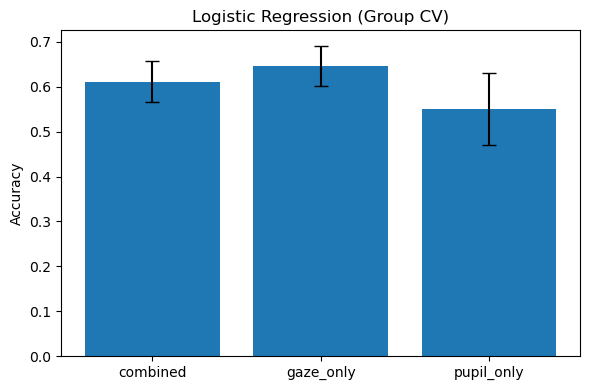

In [27]:
import matplotlib.pyplot as plt
import numpy as np

labels = summary["feature_set"]
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(x, summary["acc_mean"], yerr=summary["acc_sd"], capsize=5)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Accuracy")
ax.set_title("Logistic Regression (Group CV)")

plt.tight_layout()
plt.show()

Add early-window pupil features (trial-level)

In [2]:
import pyarrow  # quick check
import pandas as pd

df = pd.read_parquet("../data/cleaned_all_participants_right.parquet")

In [8]:
import numpy as np
import pandas as pd

EARLY_MS = (0, 1000)
LATE_MS  = (1000, 3000)

def _window_stats(t_rel_ms, y, lo, hi):
    t_rel_ms = np.asarray(t_rel_ms, dtype=float)
    y = np.asarray(y, dtype=float)

    m = (
        np.isfinite(t_rel_ms) & np.isfinite(y)
        & (t_rel_ms >= lo) & (t_rel_ms <= hi)
    )
    if not np.any(m):
        return np.nan, np.nan, np.nan, 0

    tt_s = t_rel_ms[m] / 1000.0  # seconds
    yy = y[m]
    auc = np.trapz(yy, tt_s)     # mm * s

    return float(np.mean(yy)), float(np.max(yy)), float(auc), int(m.sum())


def compute_trial_pupil_features_with_windows(trial_df: pd.DataFrame) -> dict:
    # numeric arrays ONCE
    t_rel = pd.to_numeric(trial_df["t_rel_ms"], errors="coerce").to_numpy(dtype=float)
    t_ms  = pd.to_numeric(trial_df["time_ms"], errors="coerce").to_numpy(dtype=float)
    y_bc  = pd.to_numeric(trial_df["pupil_right_bc"], errors="coerce").to_numpy(dtype=float)

    finite_y = np.isfinite(y_bc)
    if not np.any(finite_y):
        return {
            "peak_dilation": np.nan, "mean_response": np.nan, "trial_sd": np.nan,
            "mean_velocity": np.nan, "peak_velocity": np.nan,
            "early_mean": np.nan, "early_peak": np.nan, "early_auc": np.nan, "early_n": 0,
            "late_mean": np.nan,  "late_peak": np.nan,  "late_auc": np.nan,  "late_n": 0,
        }

    # base features
    peak = float(np.nanmax(y_bc))
    mean = float(np.nanmean(y_bc))
    sd   = float(np.nanstd(y_bc))

    # velocity in mm/s (robust)
    dt_s = np.diff(t_ms) / 1000.0
    dy   = np.diff(y_bc)

    vel = np.full_like(y_bc, np.nan, dtype=float)   # length n
    valid_v = np.isfinite(dt_s) & (dt_s > 0) & np.isfinite(dy)
    vel[1:][valid_v] = dy[valid_v] / dt_s[valid_v]

    mean_vel = float(np.nanmean(vel)) if np.isfinite(vel).any() else np.nan
    peak_vel = float(np.nanmax(np.abs(vel))) if np.isfinite(vel).any() else np.nan

    # window features (using numeric y_bc, not overwritten)
    early_mean, early_peak, early_auc, early_n = _window_stats(t_rel, y_bc, *EARLY_MS)
    late_mean,  late_peak,  late_auc,  late_n  = _window_stats(t_rel, y_bc, *LATE_MS)

    return {
        "peak_dilation": peak,
        "mean_response": mean,
        "trial_sd": sd,
        "mean_velocity": mean_vel,
        "peak_velocity": peak_vel,
        "early_mean": early_mean,
        "early_peak": early_peak,
        "early_auc": early_auc,
        "early_n": early_n,
        "late_mean": late_mean,
        "late_peak": late_peak,
        "late_auc": late_auc,
        "late_n": late_n,
    }


trial_keys = ["participant", "trial", "stim_category"]
pupil_feat2 = (
    df.groupby(trial_keys, observed=True, sort=False)
      .apply(lambda g: pd.Series(compute_trial_pupil_features_with_windows(g)))
      .reset_index()
)

/var/folders/g3/x3j647bn42j_bpmd_9vl047w0000gn/T/ipykernel_11501/1965206385.py:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(yy, tt_s)     # mm * s
/var/folders/g3/x3j647bn42j_bpmd_9vl047w0000gn/T/ipykernel_11501/1965206385.py:80: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series(compute_trial_pupil_features_with_windows(g)))


In [9]:
pupil_feat2[["early_n","late_n"]].describe()
print("share early_n==0:", (pupil_feat2["early_n"]==0).mean())
print("share late_n==0:", (pupil_feat2["late_n"]==0).mean())

share early_n==0: 0.5342601787487586
share late_n==0: 0.5327706057596823


In [12]:
trial_keys = ["participant","trial","stim_category"]
t0 = df.groupby(trial_keys, observed=True)["t_rel_ms"].min()
t1 = df.groupby(trial_keys, observed=True)["t_rel_ms"].max()
print(t0.describe())
print(t1.describe())
print("share min_t_rel > 0:", (t0 > 0).mean())

count    2.014000e+03
mean     3.759287e+05
std      9.191534e+05
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      4.121267e+05
max      5.249779e+06
Name: t_rel_ms, dtype: float64
count    2.014000e+03
mean     7.480174e+05
std      1.546659e+06
min      2.673019e+03
25%      2.889909e+03
50%      9.556391e+04
75%      4.780132e+05
max      6.463578e+06
Name: t_rel_ms, dtype: float64
share min_t_rel > 0: 0.4702085402184707


In [7]:
EARLY = (0, 1000)
LATE  = (1000, 3000)

one = df[(df["participant"]==1) & (df["trial"]=="Trial001") & (df["stim_category"]=="coucou_left")]
print(one["t_rel_ms"].min(), one["t_rel_ms"].max(), one["t_rel_ms"].dtype)

print("n early:", one["t_rel_ms"].between(*EARLY).sum())
print("n late :", one["t_rel_ms"].between(*LATE).sum())

2907124.0 2910015.0 float32
n early: 0
n late : 0


In [ ]:
df = pd.read_csv("../data/cleaned_all_participants_right.csv")
df.head()

/var/folders/g3/x3j647bn42j_bpmd_9vl047w0000gn/T/ipykernel_11501/1973114371.py:1: DtypeWarning: Columns (26,27,28,29,30,31,32,33,34,35,37,38,40,41,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/cleaned_all_participants_right.csv")
